In [2]:
import pandas as pd

df = pd.read_csv('MSFR_Data_AllTypes.csv')
df.head()

,Sector,Project Name,Project Name_English,Analysis,Analysis Information Extracted,Type,Type English,URL,Date,File Size,Document_ID,Project_ID,Feasibility Study Type,Recommendation,Description of Recommendation,Feasibility_Study_Complete,EIIR_Estimated,EIIR_Above_Viable,Climate Change Mentioned,LLM Model Used
0,Budovy,Nová univerzitná nemocnica v Bratislave,New University Hospital in Bratislava,NaN,NaN,Grafy a tabuľky,Graphs and tables,https://www.mfsr.sk/files/archiv/uhp/3370/76/U...,03.04.2017,66 kB,3.001,SLK_BD-034,XLSX,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Budovy,Nová univerzitná nemocnica v Bratislave,New University Hospital in Bratislava,NaN,NaN,analýza,analysis,https://www.mfsr.sk/files/archiv/uhp/3370/76/s...,03.04.2017,668 kB,3.002,SLK_BD-034,NaN,Positive,The Ministry of Finance of the Slovak Republic...,Not specified,Net present value (NPV) of 289 million euros; ...,Yes - The project is expected to be profitable...,No,gpt-4.1
2,Budovy,Rekonštrukcia Fakultnej nemocnice s poliklinik...,Reconstruction of the Faculty Hospital with Po...,NaN,NaN,analýza,analysis,https://www.mfsr.sk/files/archiv/13/stanovisko...,28.1.2019,264 kB,3.003,SLK_BD-032,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Budovy,Rekonštrukcia a dobudovanie fakúlt STU a UK - ...,Reconstruction and completion of STU and UK fa...,NaN,NaN,analýza,analysis,https://www.mfsr.sk/files/archiv/9/ACCORD_hodn...,10.9.2019,376 kB,3.004,SLK_BD-031,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Budovy,Výstavba novej univerzitnej nemocnice v Martine,Construction of a new university hospital in M...,NaN,NaN,analýza,analysis,https://www.mfsr.sk/files/archiv/62/Hodnotenie...,25.2.2022,378 kB,3.005,SLK_BD-029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
df_temp = df[['Sector', 'Document_ID', 'Feasibility Study Type']]
df_temp.groupby(['Sector', 'Feasibility Study Type'])['Document_ID'].nunique()

Sector          Feasibility Study Type                                                                  
Budovy          Complex File | Broken link on Website                                                        4
                Complex File | URL                                                                           1
                Complex File | URL pointing to Various PDFs including Maps and Tables                        3
                Complex File | Website                                                                       6
                Complex File | Zip                                                                           1
                PDF                                                                                          7
                XLSX                                                                                         1
                XLSX | Complex File | URL pointing to Various PDFs including XLSX, Docs, Maps and Tables     9
Doprava

In [18]:
df_temp_feasibility = df[['Sector', 'Project Name_English', 'Document_ID', 'Project_ID', 'Type English']]

In [19]:
df_temp_feasibility['Type English'].value_counts()

Type English
analysis                                                      207
feasibility study                                             166
evaluation                                                     63
opinion                                                         9
Updated study                                                   9
Feasibility study                                               8
update                                                          3
Graphs and tables                                               2
Updated Feasibility Study                                       2
Additional treasures from the National Highway Company...       1
Addition of assessment                                          1
Supplementing the feasibility study                             1
Study                                                           1
Updated study from investor                                     1
Questions and answers                                          

In [5]:
df_temp = df[['Sector', 'Project Name_English', 'Document_ID', 'Project_ID', 'Type English']]
len(df_temp['Project_ID'].unique())

267

In [7]:
df_temp.columns

Index(['Sector', 'Project Name_English', 'Document_ID', 'Project_ID',
       'Type English'],
      dtype='object')

In [8]:
# Group by Sector and Project_ID, then count unique Document_IDs
unique_docs_per_project = df_temp.groupby(['Sector', 'Project_ID'])['Document_ID'].nunique().reset_index()
unique_docs_per_project.columns = ['Sector', 'Project_ID', 'Unique_Document_Count']

print("Unique Document IDs per Sector and Project:")
print(unique_docs_per_project.head(10))

# If you want to see the total count
print(f"\nTotal number of Sector-Project combinations: {len(unique_docs_per_project)}")
print(f"Total unique documents across all projects: {unique_docs_per_project['Unique_Document_Count'].sum()}")

Unique Document IDs per Sector and Project:
   Sector  Project_ID  Unique_Document_Count
0  Budovy  SLK_BD-001                      2
1  Budovy  SLK_BD-002                      2
2  Budovy  SLK_BD-003                      2
3  Budovy  SLK_BD-004                      2
4  Budovy  SLK_BD-005                      2
5  Budovy  SLK_BD-006                      2
6  Budovy  SLK_BD-007                      2
7  Budovy  SLK_BD-008                      2
8  Budovy  SLK_BD-009                      2
9  Budovy  SLK_BD-010                      2

Total number of Sector-Project combinations: 267
Total unique documents across all projects: 482


In [9]:
unique_docs_per_project['Unique_Document_Count'].value_counts()

Unique_Document_Count
2    172
1     76
3     16
4      2
6      1
Name: count, dtype: int64

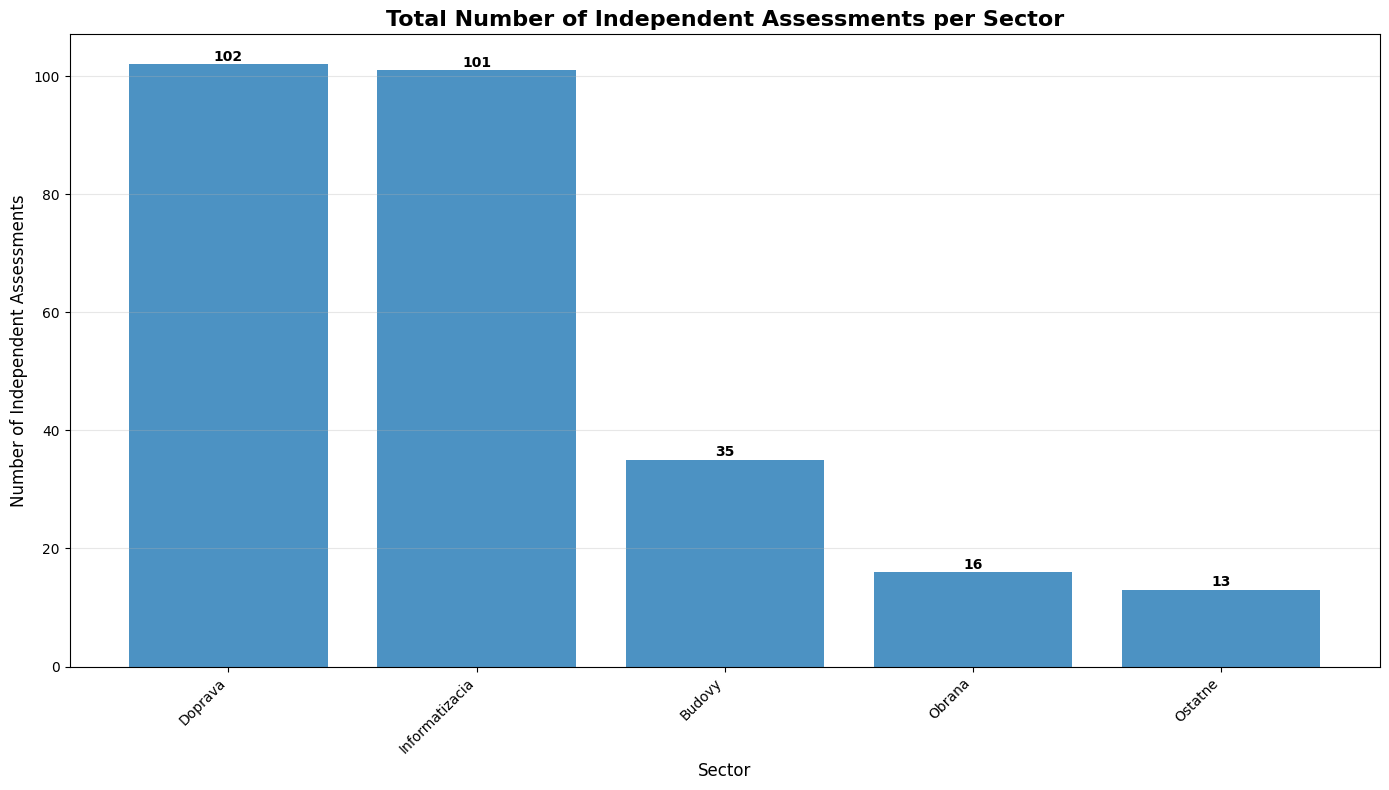

Summary Table - Total Independent Assessments per Sector:
                Total_Projects  Percentage
Sector                                    
Doprava                    102        38.2
Informatizacia             101        37.8
Budovy                      35        13.1
Obrana                      16         6.0
Ostatne                     13         4.9


Detailed Summary by Sector:
Doprava: 102 projects (38.2%)
Informatizacia: 101 projects (37.8%)
Budovy: 35 projects (13.1%)
Obrana: 16 projects (6.0%)
Ostatne: 13 projects (4.9%)

Total Projects across all sectors: 267


In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Group by Sector and Project_ID, then count unique Document_IDs
unique_docs_per_project = df_temp.groupby(['Sector', 'Project_ID'])['Document_ID'].nunique().reset_index()
unique_docs_per_project.columns = ['Sector', 'Project_ID', 'Unique_Document_Count']

# Count total projects per sector
projects_per_sector = unique_docs_per_project.groupby('Sector').size().sort_values(ascending=False)

# Create the visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Create bars
bars = ax.bar(range(len(projects_per_sector)), projects_per_sector.values, 
              color='#1f77b4', alpha=0.8)

# Add numbers above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Customize the plot
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Independent Assessments', fontsize=12)
ax.set_title('Total Number of Independent Assessments per Sector', 
             fontsize=16, fontweight='bold')
ax.set_xticks(range(len(projects_per_sector)))
ax.set_xticklabels(projects_per_sector.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Create summary table
summary_table = pd.DataFrame({
    'Total_Projects': projects_per_sector,
    'Percentage': (projects_per_sector / projects_per_sector.sum() * 100).round(1)
})

print("Summary Table - Total Independent Assessments per Sector:")
print("=" * 60)
print(summary_table)
print("\n" + "=" * 60)

# Print detailed summary
print("\nDetailed Summary by Sector:")
print("=" * 60)
for sector in projects_per_sector.index:
    count = projects_per_sector[sector]
    percentage = count / projects_per_sector.sum() * 100
    print(f"{sector}: {count} projects ({percentage:.1f}%)")

print(f"\nTotal Projects across all sectors: {projects_per_sector.sum()}")

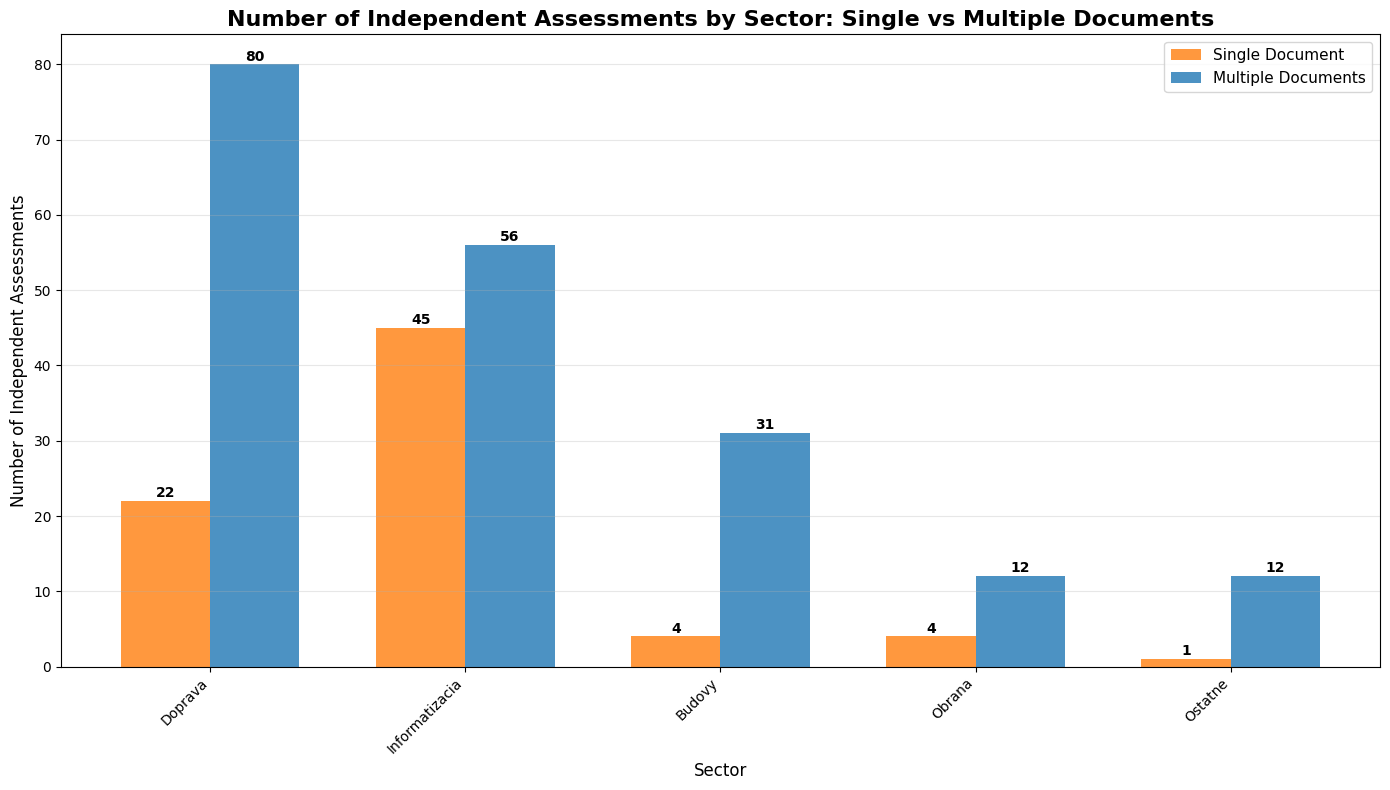

Summary Table (Sorted by Total Projects):
Document_Category  Multiple Documents  Single Document  Total_Projects  \
Sector                                                                   
Doprava                            80               22             102   
Informatizacia                     56               45             101   
Budovy                             31                4              35   
Obrana                             12                4              16   
Ostatne                            12                1              13   

Document_Category  Single_Doc_Percentage  Multiple_Doc_Percentage  
Sector                                                             
Doprava                             21.6                     78.4  
Informatizacia                      44.6                     55.4  
Budovy                              11.4                     88.6  
Obrana                              25.0                     75.0  
Ostatne                        

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Group by Sector and Project_ID, then count unique Document_IDs
unique_docs_per_project = df_temp.groupby(['Sector', 'Project_ID'])['Document_ID'].nunique().reset_index()
unique_docs_per_project.columns = ['Sector', 'Project_ID', 'Unique_Document_Count']

# Create categories for document count
unique_docs_per_project['Document_Category'] = unique_docs_per_project['Unique_Document_Count'].apply(
    lambda x: 'Single Document' if x == 1 else 'Multiple Documents'
)

# Count projects by sector and document category
sector_doc_counts = unique_docs_per_project.groupby(['Sector', 'Document_Category']).size().unstack(fill_value=0)

# Sort by total documents (descending)
sector_doc_counts['Total'] = sector_doc_counts.sum(axis=1)
sector_doc_counts_sorted = sector_doc_counts.sort_values('Total', ascending=False).drop('Total', axis=1)

# Create the side-by-side visualization
fig, ax = plt.subplots(figsize=(14, 8))

# Set up the bar positions
x = np.arange(len(sector_doc_counts_sorted.index))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, sector_doc_counts_sorted['Single Document'], width, 
               label='Single Document', color='#ff7f0e', alpha=0.8)
bars2 = ax.bar(x + width/2, sector_doc_counts_sorted['Multiple Documents'], width, 
               label='Multiple Documents', color='#1f77b4', alpha=0.8)

# Add numbers above bars
def add_value_labels(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2)

# Customize the plot
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Independent Assessments', fontsize=12)
ax.set_title('Number of Independent Assessments by Sector: Single vs Multiple Documents', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(sector_doc_counts_sorted.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Create summarization table (sorted)
summary_table = sector_doc_counts_sorted.copy()
summary_table['Total_Projects'] = summary_table.sum(axis=1)
summary_table['Single_Doc_Percentage'] = (summary_table['Single Document'] / summary_table['Total_Projects'] * 100).round(1)
summary_table['Multiple_Doc_Percentage'] = (summary_table['Multiple Documents'] / summary_table['Total_Projects'] * 100).round(1)

print("Summary Table (Sorted by Total Projects):")
print("=" * 90)
print(summary_table)
print("\n" + "=" * 90)

# Print detailed summary statistics (sorted)
print("\nDetailed Summary by Sector (Sorted by Total Projects):")
print("=" * 90)
for sector in summary_table.index:
    single = summary_table.loc[sector, 'Single Document']
    multiple = summary_table.loc[sector, 'Multiple Documents']
    total = summary_table.loc[sector, 'Total_Projects']
    print(f"{sector}:")
    print(f"  Single Document Projects: {single} ({single/total*100:.1f}%)")
    print(f"  Multiple Document Projects: {multiple} ({multiple/total*100:.1f}%)")
    print(f"  Total Projects: {total}")
    print()

# Overall statistics
total_single = summary_table['Single Document'].sum()
total_multiple = summary_table['Multiple Documents'].sum()
total_projects = total_single + total_multiple

print("OVERALL STATISTICS:")
print("=" * 40)
print(f"Total Projects with Single Document: {total_single} ({total_single/total_projects*100:.1f}%)")
print(f"Total Projects with Multiple Documents: {total_multiple} ({total_multiple/total_projects*100:.1f}%)")
print(f"Total Projects: {total_projects}")

In [ ]:
# Create the filtered dataframe
df_temp_feasibility = df[['Sector', 'Project Name_English', 'Document_ID', 'Project_ID', 'Type English']]

# Define feasibility study types (case-insensitive)
feasibility_types = [
    'feasibility study',
    'updated study', 
    'feasibility study',
    'updated feasibility study'
]

# Create a boolean mask for feasibility studies (case-insensitive)
feasibility_mask = df_temp_feasibility['Type English'].str.lower().str.strip().isin([ft.lower().strip() for ft in feasibility_types])

# Filter for feasibility studies
feasibility_studies = df_temp_feasibility[feasibility_mask]

# Count unique projects with feasibility studies
projects_with_feasibility = feasibility_studies['Project_ID'].nunique()

# Count by sector
feasibility_by_sector = feasibility_studies.groupby('Sector')['Project_ID'].nunique().sort_values(ascending=False)

print("FEASIBILITY STUDY ANALYSIS")
print("=" * 50)
print(f"Total Independent Assessments with feasibility studies: {projects_with_feasibility}")
print(f"Total projects in dataset: {df_temp_feasibility['Project_ID'].nunique()}")
print(f"Percentage of projects with feasibility studies: {projects_with_feasibility/df_temp_feasibility['Project_ID'].nunique()*100:.1f}%")

print("\nProjects with Feasibility Studies by Sector:")
print("=" * 50)
for sector in feasibility_by_sector.index:
    count = feasibility_by_sector[sector]
    total_sector_projects = df_temp_feasibility[df_temp_feasibility['Sector'] == sector]['Project_ID'].nunique()
    percentage = count / total_sector_projects * 100
    print(f"{sector}: {count} projects ({percentage:.1f}% of sector projects)")

print("\nDetailed breakdown by Type English:")
print("=" * 50)
type_breakdown = feasibility_studies['Type English'].value_counts()
for doc_type, count in type_breakdown.items():
    print(f"'{doc_type}': {count} documents")

# Create a summary table
summary_table = pd.DataFrame({
    'Sector': feasibility_by_sector.index,
    'Projects_with_Feasibility': feasibility_by_sector.values,
    'Total_Sector_Projects': [df_temp_feasibility[df_temp_feasibility['Sector'] == sector]['Project_ID'].nunique() 
                             for sector in feasibility_by_sector.index],
    'Feasibility_Percentage': [(feasibility_by_sector[sector] / 
                               df_temp_feasibility[df_temp_feasibility['Sector'] == sector]['Project_ID'].nunique() * 100)
                              for sector in feasibility_by_sector.index]
})

summary_table['Feasibility_Percentage'] = summary_table['Feasibility_Percentage'].round(1)

print("\nSummary Table:")
print("=" * 80)
print(summary_table)

FEASIBILITY STUDY ANALYSIS
Total projects with feasibility studies: 181
Total projects in dataset: 267
Percentage of projects with feasibility studies: 67.8%

Projects with Feasibility Studies by Sector:
Doprava: 74 projects (72.5% of sector projects)
Informatizacia: 54 projects (53.5% of sector projects)
Budovy: 30 projects (85.7% of sector projects)
Ostatne: 12 projects (92.3% of sector projects)
Obrana: 11 projects (68.8% of sector projects)

Detailed breakdown by Type English:
'feasibility study': 166 documents
'Updated study': 9 documents
'Feasibility study': 8 documents
'Updated Feasibility Study': 2 documents

Summary Table:
           Sector  Projects_with_Feasibility  Total_Sector_Projects  \
0         Doprava                         74                    102   
1  Informatizacia                         54                    101   
2          Budovy                         30                     35   
3         Ostatne                         12                     13   
4    

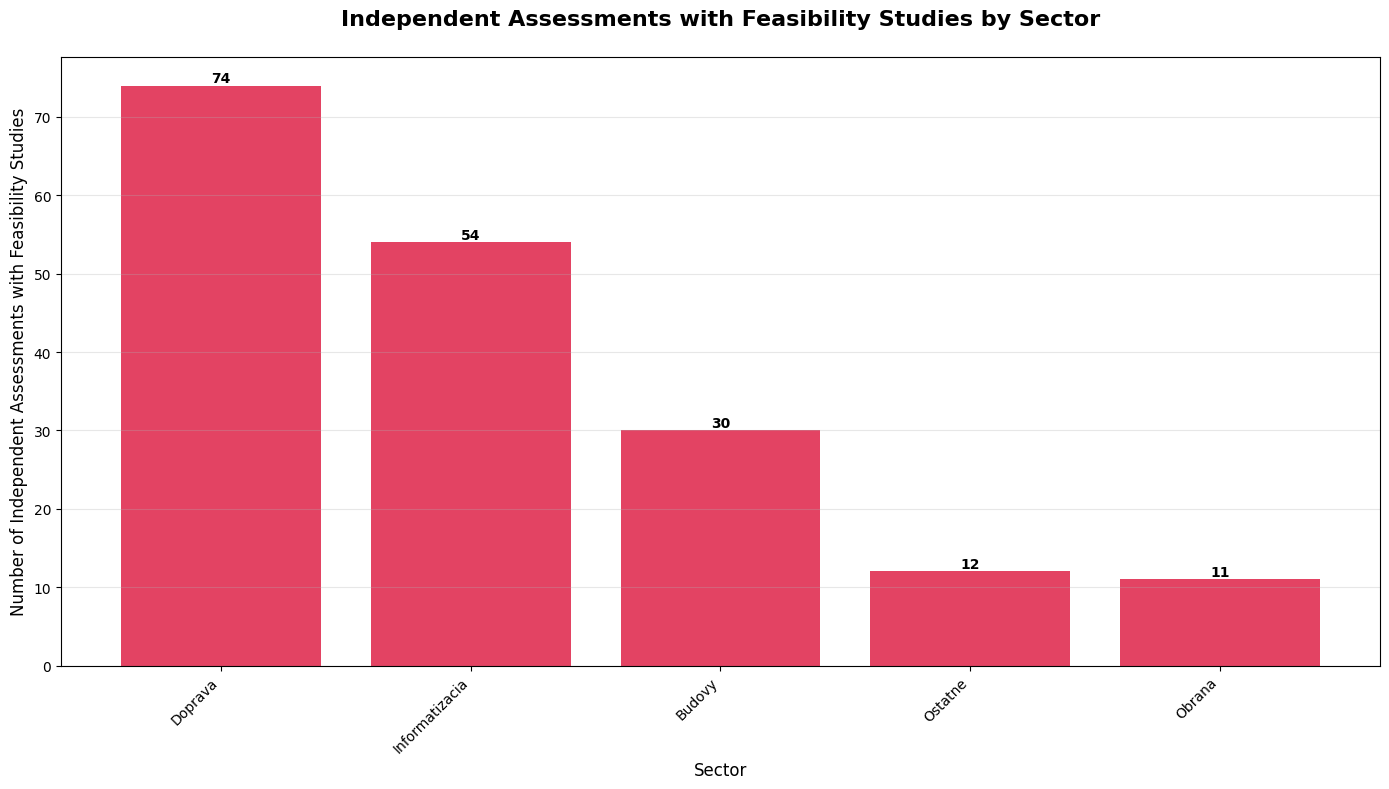

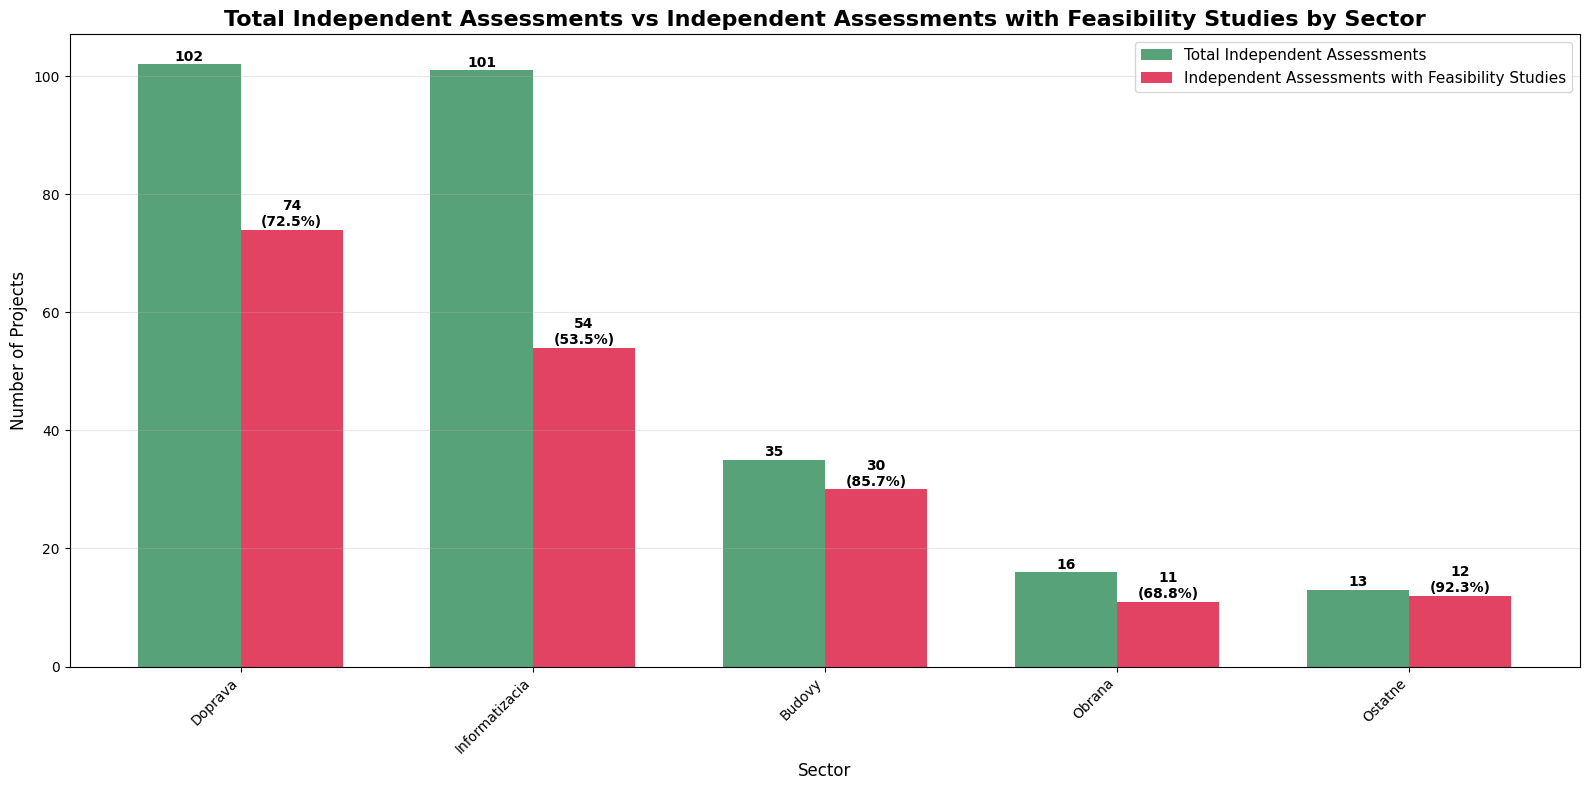

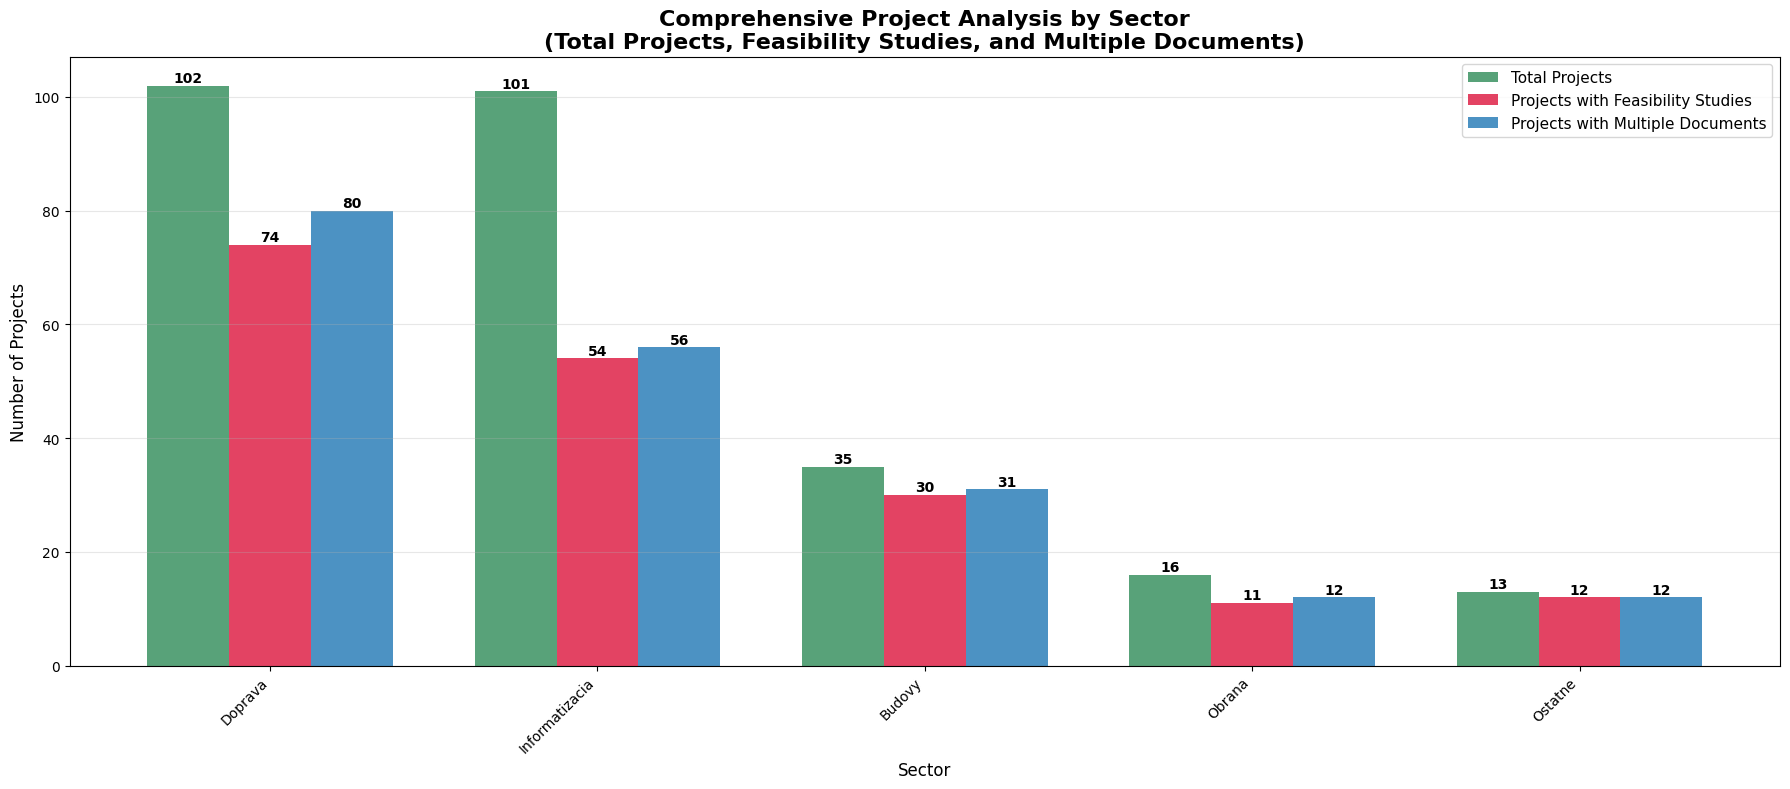

COMPREHENSIVE SUMMARY TABLE:
                Total_Projects  Projects_with_Feasibility  \
Sector                                                      
Doprava                    102                         74   
Informatizacia             101                         54   
Budovy                      35                         30   
Obrana                      16                         11   
Ostatne                     13                         12   

                Projects_with_Multiple_Docs  Feasibility_Percentage  \
Sector                                                                
Doprava                                  80                    72.5   
Informatizacia                           56                    53.5   
Budovy                                   31                    85.7   
Obrana                                   12                    68.8   
Ostatne                                  12                    92.3   

                Multiple_Docs_Percentage  
Se

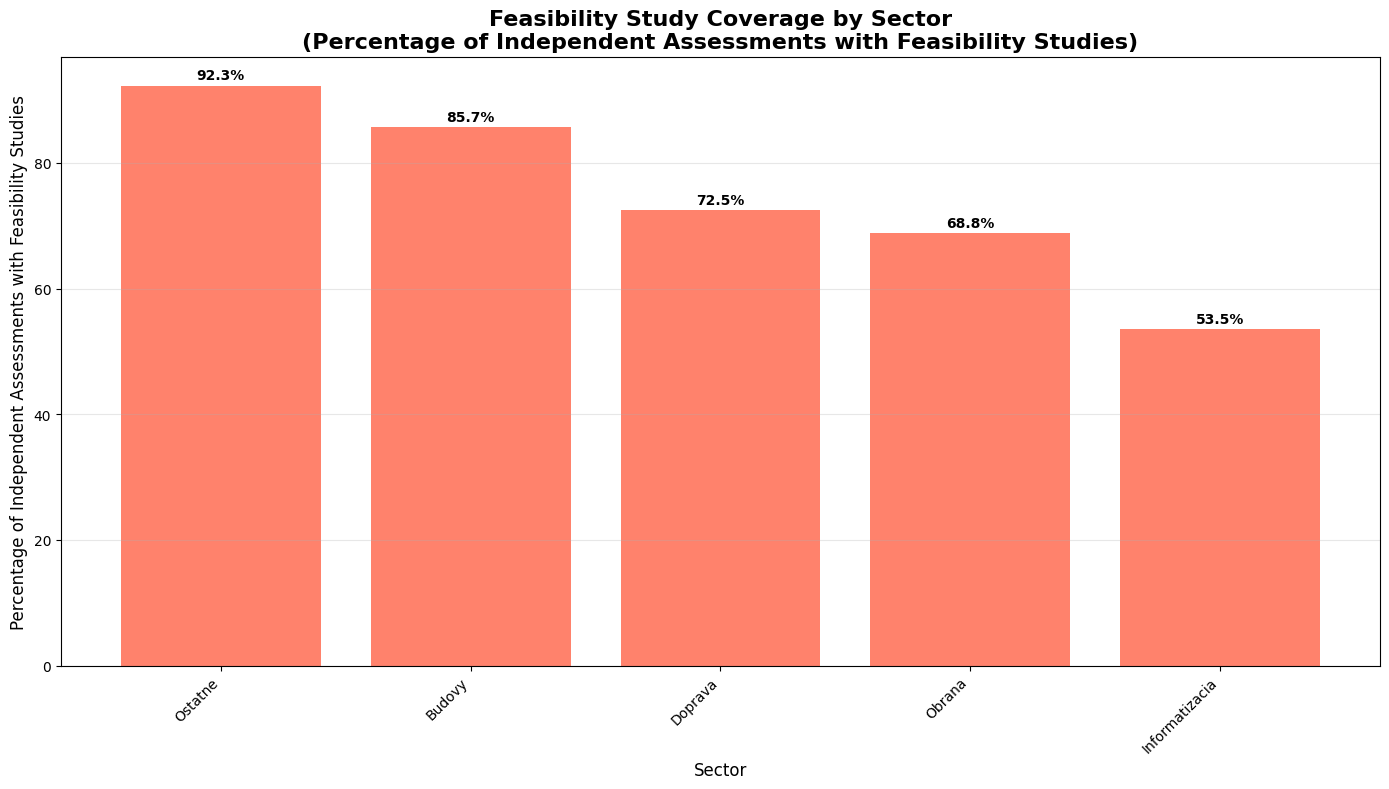

FEASIBILITY STUDY ANALYSIS
Total projects with feasibility studies: 181
Total projects in dataset: 267
Overall feasibility study coverage: 67.8%

Detailed breakdown by Type English:
'feasibility study': 166 documents
'Updated study': 9 documents
'Feasibility study': 8 documents
'Updated Feasibility Study': 2 documents

Summary Table:
                Total_Projects  Projects_with_Feasibility  \
Sector                                                      
Doprava                    102                         74   
Informatizacia             101                         54   
Budovy                      35                         30   
Obrana                      16                         11   
Ostatne                     13                         12   

                Feasibility_Percentage  
Sector                                  
Doprava                           72.5  
Informatizacia                    53.5  
Budovy                            85.7  
Obrana                         

In [28]:
# FEASIBILITY STUDY ANALYSIS
# Create the filtered dataframe
df_temp_feasibility = df[['Sector', 'Project Name_English', 'Document_ID', 'Project_ID', 'Type English']]

# Define feasibility study types (case-insensitive)
feasibility_types = [
    'feasibility study',
    'updated study', 
    'feasibility study',
    'updated feasibility study'
]

# Create a boolean mask for feasibility studies (case-insensitive)
feasibility_mask = df_temp_feasibility['Type English'].str.lower().str.strip().isin([ft.lower().strip() for ft in feasibility_types])

# Filter for feasibility studies
feasibility_studies = df_temp_feasibility[feasibility_mask]

# Count unique projects with feasibility studies by sector
feasibility_by_sector = feasibility_studies.groupby('Sector')['Project_ID'].nunique().sort_values(ascending=False)

# Count total projects by sector for comparison
total_projects_by_sector = df_temp_feasibility.groupby('Sector')['Project_ID'].nunique().sort_values(ascending=False)

# 1. SEPARATE VISUALIZATION - Feasibility Studies Only
fig, ax = plt.subplots(figsize=(14, 8))

# Create bars
bars = ax.bar(range(len(feasibility_by_sector)), feasibility_by_sector.values, 
              color='#DC143C', alpha=0.8)

# Add numbers above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
            f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# Customize the plot
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Independent Assessments with Feasibility Studies', fontsize=12)
ax.set_title('Independent Assessments with Feasibility Studies by Sector\n', 
             fontsize=16, fontweight='bold')
ax.set_xticks(range(len(feasibility_by_sector)))
ax.set_xticklabels(feasibility_by_sector.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 2. COMBINED VISUALIZATION - Feasibility Studies alongside Document Count Analysis (with percentages)
# Prepare data for combined visualization
combined_data = pd.DataFrame({
    'Total_Projects': total_projects_by_sector,
    'Projects_with_Feasibility': feasibility_by_sector
}).fillna(0)

# Sort by total projects
combined_data = combined_data.sort_values('Total_Projects', ascending=False)

# Calculate feasibility percentage
combined_data['Feasibility_Percentage'] = (combined_data['Projects_with_Feasibility'] / combined_data['Total_Projects'] * 100).round(1)

# Create the combined visualization
fig, ax = plt.subplots(figsize=(16, 8))

# Set up the bar positions
x = np.arange(len(combined_data.index))
width = 0.35

# Create bars
bars1 = ax.bar(x - width/2, combined_data['Total_Projects'], width, 
               label='Total Independent Assessments', color='#2E8B57', alpha=0.8)
bars2 = ax.bar(x + width/2, combined_data['Projects_with_Feasibility'], width, 
               label='Independent Assessments with Feasibility Studies', color='#DC143C', alpha=0.8)

# Add numbers above bars
def add_value_labels(bars, percentages=None):
    for i, bar in enumerate(bars):
        height = bar.get_height()
        if percentages is not None and i < len(percentages):
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}\n({percentages[i]:.1f}%)', ha='center', va='bottom', fontweight='bold')
        else:
            ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                    f'{int(height)}', ha='center', va='bottom', fontweight='bold')

add_value_labels(bars1)
add_value_labels(bars2, combined_data['Feasibility_Percentage'].values)

# Customize the plot
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Projects', fontsize=12)
ax.set_title('Total Independent Assessments vs Independent Assessments with Feasibility Studies by Sector', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(combined_data.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# 4. COMPREHENSIVE VISUALIZATION - All Three Metrics
# Recreate the document analysis data for multiple documents
unique_docs_per_project_comp = df_temp.groupby(['Sector', 'Project_ID'])['Document_ID'].nunique().reset_index()
unique_docs_per_project_comp.columns = ['Sector', 'Project_ID', 'Unique_Document_Count']

# Create categories for document count
unique_docs_per_project_comp['Document_Category'] = unique_docs_per_project_comp['Unique_Document_Count'].apply(
    lambda x: 'Single Document' if x == 1 else 'Multiple Documents'
)

# Get projects with multiple documents
projects_multiple_docs = unique_docs_per_project_comp[unique_docs_per_project_comp['Document_Category'] == 'Multiple Documents']
multiple_docs_by_sector = projects_multiple_docs.groupby('Sector').size()

# Prepare comprehensive data
comprehensive_data = pd.DataFrame({
    'Total_Projects': total_projects_by_sector,
    'Projects_with_Feasibility': feasibility_by_sector,
    'Projects_with_Multiple_Docs': multiple_docs_by_sector
}).fillna(0)

# Sort by total projects
comprehensive_data = comprehensive_data.sort_values('Total_Projects', ascending=False)

# Create the comprehensive visualization
fig, ax = plt.subplots(figsize=(18, 8))

# Set up the bar positions
x = np.arange(len(comprehensive_data.index))
width = 0.25

# Create bars
bars1 = ax.bar(x - width, comprehensive_data['Total_Projects'], width, 
               label='Total Projects', color='#2E8B57', alpha=0.8)
bars2 = ax.bar(x, comprehensive_data['Projects_with_Feasibility'], width, 
               label='Projects with Feasibility Studies', color='#DC143C', alpha=0.8)
bars3 = ax.bar(x + width, comprehensive_data['Projects_with_Multiple_Docs'], width, 
               label='Projects with Multiple Documents', color='#1f77b4', alpha=0.8)

# Add numbers above bars
def add_value_labels_comprehensive(bars):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.1,
                f'{int(height)}', ha='center', va='bottom', fontweight='bold')

add_value_labels_comprehensive(bars1)
add_value_labels_comprehensive(bars2)
add_value_labels_comprehensive(bars3)

# Customize the plot
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Number of Projects', fontsize=12)
ax.set_title('Comprehensive Project Analysis by Sector\n(Total Projects, Feasibility Studies, and Multiple Documents)', 
             fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(comprehensive_data.index, rotation=45, ha='right')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print comprehensive summary table
print("COMPREHENSIVE SUMMARY TABLE:")
print("=" * 100)
comprehensive_summary = comprehensive_data.copy()
comprehensive_summary['Feasibility_Percentage'] = (comprehensive_summary['Projects_with_Feasibility'] / comprehensive_summary['Total_Projects'] * 100).round(1)
comprehensive_summary['Multiple_Docs_Percentage'] = (comprehensive_summary['Projects_with_Multiple_Docs'] / comprehensive_summary['Total_Projects'] * 100).round(1)
print(comprehensive_summary)

# Print comprehensive summary table
print("COMPREHENSIVE SUMMARY TABLE:")
print("=" * 100)
comprehensive_summary = comprehensive_data.copy()
comprehensive_summary['Feasibility_Percentage'] = (comprehensive_summary['Projects_with_Feasibility'] / comprehensive_summary['Total_Projects'] * 100).round(1)
comprehensive_summary['Multiple_Docs_Percentage'] = (comprehensive_summary['Projects_with_Multiple_Docs'] / comprehensive_summary['Total_Projects'] * 100).round(1)
print(comprehensive_summary)

# 3. PERCENTAGE VISUALIZATION - Feasibility Study Coverage (Sorted by Percentage)
feasibility_percentage = (combined_data['Projects_with_Feasibility'] / combined_data['Total_Projects'] * 100).round(1)

# Sort by percentage in descending order
feasibility_percentage_sorted = feasibility_percentage.sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(14, 8))

# Create bars
bars = ax.bar(range(len(feasibility_percentage_sorted)), feasibility_percentage_sorted.values, 
              color='#FF6347', alpha=0.8)

# Add numbers above bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.5,
            f'{height:.1f}%', ha='center', va='bottom', fontweight='bold')

# Customize the plot
ax.set_xlabel('Sector', fontsize=12)
ax.set_ylabel('Percentage of Independent Assessments with Feasibility Studies', fontsize=12)
ax.set_title('Feasibility Study Coverage by Sector\n(Percentage of Independent Assessments with Feasibility Studies)', 
             fontsize=16, fontweight='bold')
ax.set_xticks(range(len(feasibility_percentage_sorted)))
ax.set_xticklabels(feasibility_percentage_sorted.index, rotation=45, ha='right')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary statistics
print("FEASIBILITY STUDY ANALYSIS")
print("=" * 60)
total_feasibility_projects = feasibility_by_sector.sum()
total_all_projects = total_projects_by_sector.sum()
print(f"Total projects with feasibility studies: {total_feasibility_projects}")
print(f"Total projects in dataset: {total_all_projects}")
print(f"Overall feasibility study coverage: {total_feasibility_projects/total_all_projects*100:.1f}%")

print("\nDetailed breakdown by Type English:")
print("=" * 60)
type_breakdown = feasibility_studies['Type English'].value_counts()
for doc_type, count in type_breakdown.items():
    print(f"'{doc_type}': {count} documents")

print("\nSummary Table:")
print("=" * 80)
summary_table = combined_data.copy()
summary_table['Feasibility_Percentage'] = feasibility_percentage
print(summary_table)